# Comparison of CenterPoint and BEVFusion on nuScenes 20% and 40% subsets

This notebook compares CenterPoint and BEVFusion trained on reduced nuScenes training subsets.

The goal is to compare:
- training loss behavior
- final NDS and mAP
- global nuScenes error metrics
- per-class detection performance

# Import

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from typing import Dict, Final, List
from pprint import pprint


# Config

In [21]:
# Root project directory
PROJECT_ROOT: Final[Path] = (
    Path.cwd().resolve().parent
)

print("Project root:")
print(PROJECT_ROOT)

CONFIG: Dict[str, object] = {

    # Results directory
    "metrics_dir":
        PROJECT_ROOT / "results" / "final_metrics",

    # Experiment metric files
    "metrics_files": [

        "centerpoint_nuscenes_20pct_10ep_run1_metrics.csv",

        "centerpoint_nuscenes_40pct_10ep_run1_metrics.csv",

        "bevfusion_nuscenes_20pct_10ep_run1_metrics.csv",

        "bevfusion_nuscenes_40pct_10ep_run1_metrics.csv",
    ],
}

pprint(CONFIG)

Project root:
/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning
{'metrics_dir': PosixPath('/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/results/final_metrics'),
 'metrics_files': ['centerpoint_nuscenes_20pct_10ep_run1_metrics.csv',
                   'centerpoint_nuscenes_40pct_10ep_run1_metrics.csv',
                   'bevfusion_nuscenes_20pct_10ep_run1_metrics.csv',
                   'bevfusion_nuscenes_40pct_10ep_run1_metrics.csv']}


# Load experiment metrics

This section loads the cleaned metrics exported from each experiment notebook and combines them into a single dataframe for comparison.

In [22]:
METRICS_DIR: Final[Path] = CONFIG["metrics_dir"]
metrics_files: Final[List[str]] = CONFIG["metrics_files"]

dfs: List[pd.DataFrame] = []

for file_name in metrics_files:

    file_path: Path = METRICS_DIR / file_name

    df: pd.DataFrame = pd.read_csv(file_path)

    dfs.append(df)

metrics_df: pd.DataFrame = pd.concat(dfs, ignore_index=True)

print(metrics_df.shape)

metrics_df.head()

(36, 105)


,run,epoch,step,car_AP_0.5,car_AP_1.0,car_AP_2.0,car_AP_4.0,car_ATE,car_ASE,car_AOE,...,traffic_cone_AOE,traffic_cone_AVE,traffic_cone_AAE,NDS,mAP,model,subset,experiment_name,gpu_type,max_epochs
0,20260511_181619,NaN,1,0.3929,0.5434,0.6480,0.7065,0.3293,0.1811,0.7177,...,NaN,NaN,NaN,0.278986,0.198266,centerpoint,20pct,centerpoint_nuscenes_20pct_10ep_run1,rtx4090,10
1,20260511_181619,NaN,2,0.4920,0.6376,0.7106,0.7526,0.2709,0.1770,0.5138,...,NaN,NaN,NaN,0.337484,0.263817,centerpoint,20pct,centerpoint_nuscenes_20pct_10ep_run1,rtx4090,10
2,20260511_181619,NaN,3,0.5181,0.6636,0.7349,0.7708,0.2696,0.1727,0.4092,...,NaN,NaN,NaN,0.386113,0.304838,centerpoint,20pct,centerpoint_nuscenes_20pct_10ep_run1,rtx4090,10
3,20260511_181619,NaN,4,0.5526,0.6964,0.7639,0.7939,0.2520,0.1692,0.3812,...,NaN,NaN,NaN,0.414214,0.340238,centerpoint,20pct,centerpoint_nuscenes_20pct_10ep_run1,rtx4090,10
4,20260512_001903,NaN,5,0.5749,0.7132,0.7761,0.8062,0.2405,0.1695,0.3280,...,NaN,NaN,NaN,0.434577,0.351107,centerpoint,20pct,centerpoint_nuscenes_20pct_10ep_run1,rtx4090,10


# Inspect loaded experiments

This section verifies that all experiments were loaded correctly and checks the available metadata and evaluation metrics.

In [23]:
print("Experiments:")
print(metrics_df["experiment_name"].unique())

print("\nModels:")
print(metrics_df["model"].unique())

print("\nSubsets:")
print(metrics_df["subset"].unique())

print("\nDataframe shape:")
print(metrics_df.shape)

Experiments:
['centerpoint_nuscenes_20pct_10ep_run1'
 'centerpoint_nuscenes_40pct_10ep_run1'
 'bevfusion_nuscenes_20pct_10ep_run1' 'bevfusion_nuscenes_40pct_10ep_run1']

Models:
['centerpoint' 'bevfusion']

Subsets:
['20pct' '40pct']

Dataframe shape:
(36, 105)


In [24]:
metrics_df[
    [
        "experiment_name",
        "epoch",
        "step",
        "NDS",
        "mAP",
    ]
].head(20)

,experiment_name,epoch,step,NDS,mAP
0,centerpoint_nuscenes_20pct_10ep_run1,NaN,1,0.278986,0.198266
1,centerpoint_nuscenes_20pct_10ep_run1,NaN,2,0.337484,0.263817
2,centerpoint_nuscenes_20pct_10ep_run1,NaN,3,0.386113,0.304838
3,centerpoint_nuscenes_20pct_10ep_run1,NaN,4,0.414214,0.340238
4,centerpoint_nuscenes_20pct_10ep_run1,NaN,5,0.434577,0.351107
5,centerpoint_nuscenes_20pct_10ep_run1,NaN,6,0.450570,0.358013
6,centerpoint_nuscenes_20pct_10ep_run1,NaN,7,0.473044,0.388224
7,centerpoint_nuscenes_20pct_10ep_run1,NaN,8,0.479367,0.393272
8,centerpoint_nuscenes_20pct_10ep_run1,NaN,9,0.486864,0.398193
9,centerpoint_nuscenes_20pct_10ep_run1,NaN,10,0.485113,0.397954


# Create experiment labels

This section creates simplified experiment labels used in plots and comparison tables.

In [25]:
# Create readable experiment labels
metrics_df["experiment_label"] = (
    metrics_df["model"].str.title()
    + " "
    + metrics_df["subset"].str.replace("pct", "%", regex=False)
)

metrics_df[
    [
        "experiment_name",
        "experiment_label",
        "step",
        "NDS",
        "mAP",
    ]
].head(20)

,experiment_name,experiment_label,step,NDS,mAP
0,centerpoint_nuscenes_20pct_10ep_run1,Centerpoint 20%,1,0.278986,0.198266
1,centerpoint_nuscenes_20pct_10ep_run1,Centerpoint 20%,2,0.337484,0.263817
2,centerpoint_nuscenes_20pct_10ep_run1,Centerpoint 20%,3,0.386113,0.304838
3,centerpoint_nuscenes_20pct_10ep_run1,Centerpoint 20%,4,0.414214,0.340238
4,centerpoint_nuscenes_20pct_10ep_run1,Centerpoint 20%,5,0.434577,0.351107
5,centerpoint_nuscenes_20pct_10ep_run1,Centerpoint 20%,6,0.450570,0.358013
6,centerpoint_nuscenes_20pct_10ep_run1,Centerpoint 20%,7,0.473044,0.388224
7,centerpoint_nuscenes_20pct_10ep_run1,Centerpoint 20%,8,0.479367,0.393272
8,centerpoint_nuscenes_20pct_10ep_run1,Centerpoint 20%,9,0.486864,0.398193
9,centerpoint_nuscenes_20pct_10ep_run1,Centerpoint 20%,10,0.485113,0.397954


# Final experiment metrics

This section extracts the final evaluation metrics from each experiment for direct comparison.


In [26]:
# Keep only the final evaluation step of each experiment
final_metrics_df = (
    metrics_df
    .sort_values("step")
    .groupby("experiment_label")
    .tail(1)
)

# Select key metrics
summary_df: pd.DataFrame =  final_metrics_df[
    [
        "experiment_label",
        "NDS",
        "mAP",
        "mATE",
        "mASE",
        "mAOE",
        "mAVE",
        "mAAE",
    ]
].copy()

# Round values for display
summary_df = summary_df.round(4)

# Sort experiments
summary_df = summary_df.sort_values("NDS", ascending=False)

summary_df

,experiment_label,NDS,mAP,mATE,mASE,mAOE,mAVE,mAAE
35,Bevfusion 40%,0.6092,0.5490,0.3141,0.2824,0.4798,0.3772,0.1993
19,Centerpoint 40%,0.5712,0.4773,0.3488,0.2725,0.4419,0.4004,0.2111
9,Centerpoint 20%,0.4851,0.3980,0.3770,0.2827,0.6237,0.6239,0.2313
25,Bevfusion 20%,0.4686,0.4489,0.3700,0.3014,0.6561,0.9719,0.2590


# Final detection performance comparison

This section compares the final NDS and mAP scores obtained by each experiment.

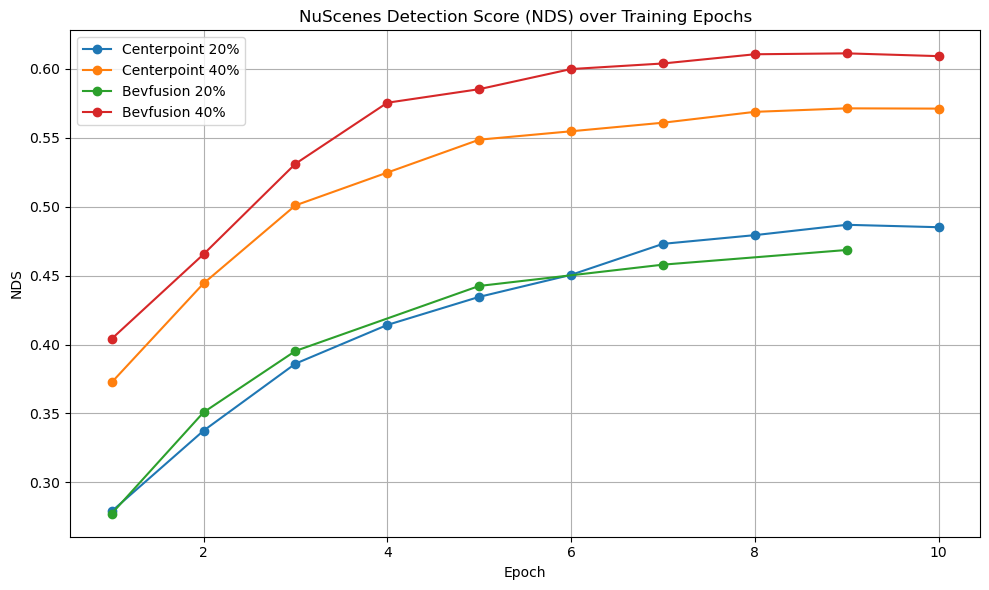

In [27]:
plt.figure(figsize=(10, 6))

for label in metrics_df["experiment_label"].unique():

    exp_df = metrics_df[
        metrics_df["experiment_label"] == label
    ]

    plt.plot(
        exp_df["step"],
        exp_df["NDS"],
        marker="o",
        label=label,
    )

plt.xlabel("Epoch")
plt.ylabel("NDS")

plt.title(
    "NuScenes Detection Score (NDS) over Training Epochs"
)

plt.legend()

plt.grid()

plt.tight_layout()

plt.show()

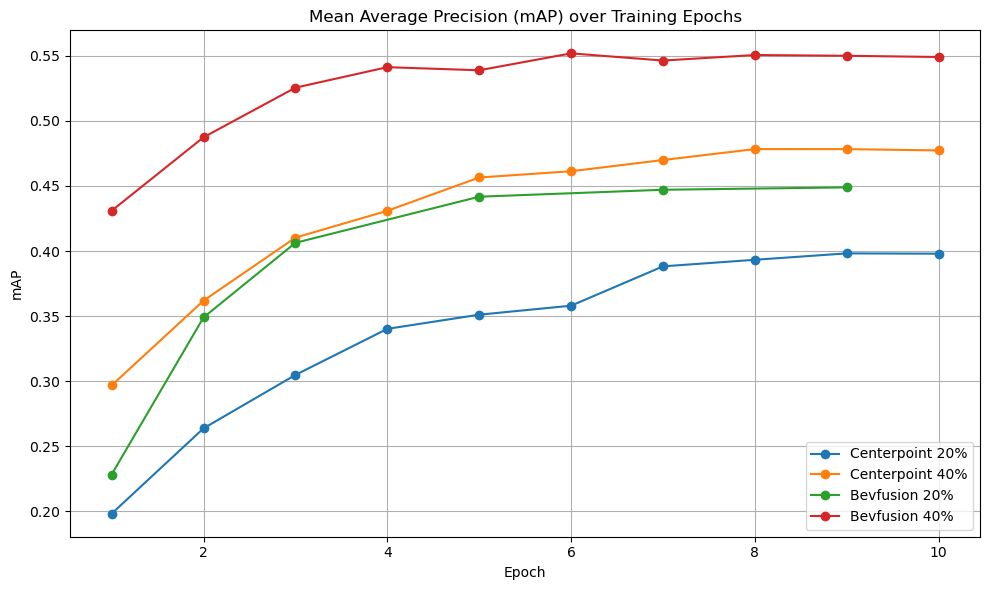

In [28]:
plt.figure(figsize=(10, 6))

for label in metrics_df["experiment_label"].unique():

    exp_df = metrics_df[
        metrics_df["experiment_label"] == label
    ]

    plt.plot(
        exp_df["step"],
        exp_df["mAP"],
        marker="o",
        label=label,
    )

plt.xlabel("Epoch")
plt.ylabel("mAP")

plt.title(
    "Mean Average Precision (mAP) over Training Epochs"
)

plt.legend()

plt.grid()

plt.tight_layout()

plt.show()

# Global error evolution

This section compares the evolution of the global nuScenes error metrics across training epochs for all experiments.

Lower values indicate better performance.

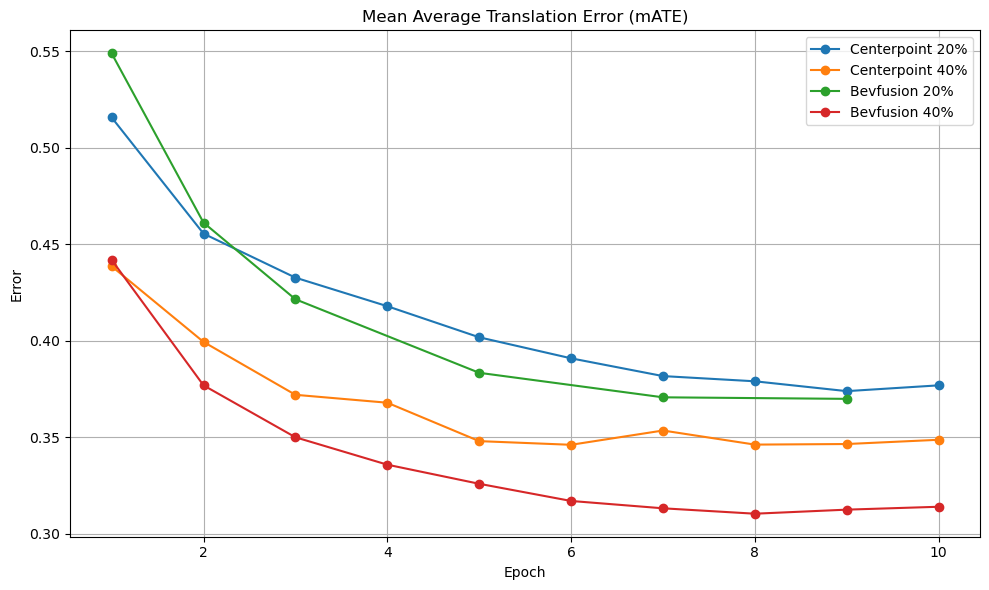

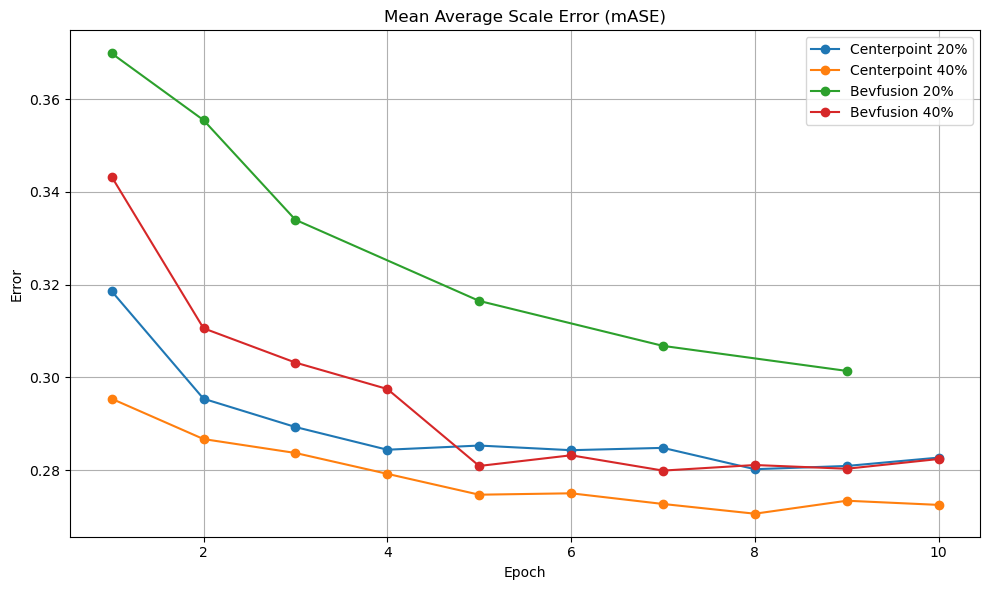

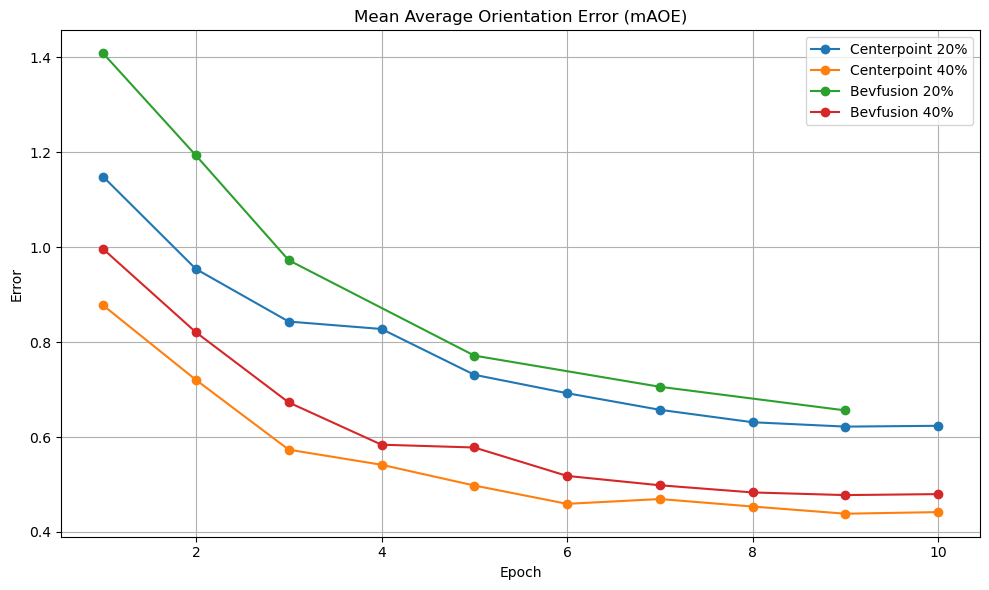

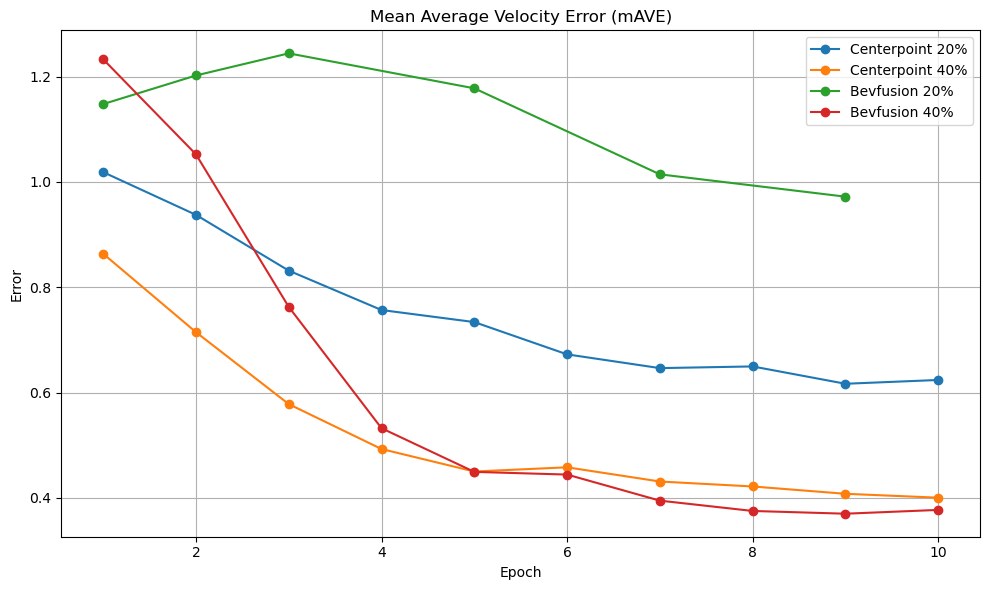

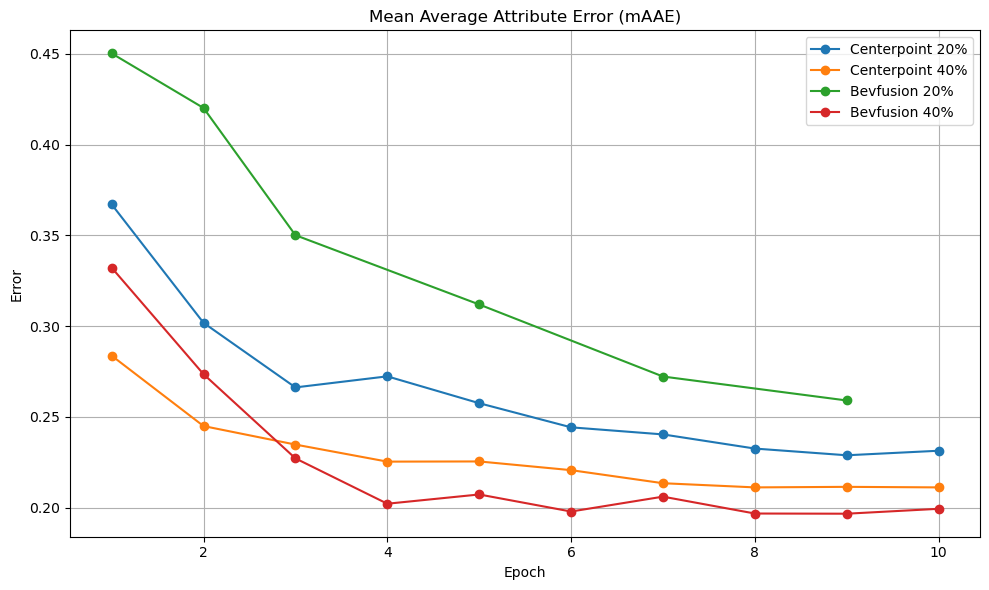

In [29]:
error_metrics: Dict[str, str] = {
    "mATE": "Mean Average Translation Error (mATE)",
    "mASE": "Mean Average Scale Error (mASE)",
    "mAOE": "Mean Average Orientation Error (mAOE)",
    "mAVE": "Mean Average Velocity Error (mAVE)",
    "mAAE": "Mean Average Attribute Error (mAAE)",
}

for metric, title in error_metrics.items():

    plt.figure(figsize=(10, 6))

    for label in metrics_df["experiment_label"].unique():

        exp_df = metrics_df[
            metrics_df["experiment_label"] == label
        ]

        plt.plot(
            exp_df["step"],
            exp_df[metric],
            marker="o",
            label=label,
        )

    plt.xlabel("Epoch")
    plt.ylabel("Error")

    plt.title(title)

    plt.legend()

    plt.grid()

    plt.tight_layout()

    plt.show()

# Per-class detection performance

This section compares the final Average Precision (AP) obtained for each nuScenes object class.

In [36]:
classes: List[str] = [
    "car",
    "truck",
    "bus",
    "trailer",
    "construction_vehicle",
    "pedestrian",
    "motorcycle",
    "bicycle",
    "traffic_cone",
    "barrier",
]

per_class_ap: pd.DataFrame = pd.DataFrame(index=classes)

for _, row in final_metrics_df.iterrows():

    label = row["experiment_label"]

    per_class_ap[label] = [

        row[
            [
                f"{cls}_AP_0.5",
                f"{cls}_AP_1.0",
                f"{cls}_AP_2.0",
                f"{cls}_AP_4.0",
            ]
        ].mean()

        for cls in classes
    ]

per_class_ap = per_class_ap.round(3)

per_class_ap = per_class_ap[
    [
        "Bevfusion 40%",
        "Bevfusion 20%",
        "Centerpoint 40%",
        "Centerpoint 20%",

    ]
]

per_class_ap

,Bevfusion 40%,Bevfusion 20%,Centerpoint 40%,Centerpoint 20%
car,0.838,0.803,0.798,0.747
truck,0.480,0.335,0.462,0.378
bus,0.565,0.381,0.615,0.554
trailer,0.252,0.139,0.247,0.178
construction_vehicle,0.190,0.107,0.099,0.099
pedestrian,0.838,0.823,0.783,0.703
motorcycle,0.624,0.514,0.440,0.372
bicycle,0.470,0.282,0.277,0.172
traffic_cone,0.718,0.654,0.545,0.426
barrier,0.516,0.451,0.507,0.351


In [31]:
# Measure the per-class AP difference between
# BEVFusion and CenterPoint at each dataset size.

model_gap_df: pd.DataFrame = pd.DataFrame(index=classes)

model_gap_df["model_gap_20pct"] = (
    per_class_ap["Bevfusion 20%"]
    - per_class_ap["Centerpoint 20%"]
)

model_gap_df["model_gap_40pct"] = (
    per_class_ap["Bevfusion 40%"]
    - per_class_ap["Centerpoint 40%"]
)

model_gap_df = model_gap_df.round(3)

model_gap_df = model_gap_df.sort_values(
    by="model_gap_40pct",
    ascending=False,
)

model_gap_df

,model_gap_20pct,model_gap_40pct
bicycle,0.110,0.193
motorcycle,0.142,0.184
traffic_cone,0.228,0.173
construction_vehicle,0.008,0.091
pedestrian,0.120,0.055
car,0.056,0.040
truck,-0.043,0.018
barrier,0.100,0.009
trailer,-0.039,0.005
bus,-0.173,-0.050


**Observations**

- BEVFusion improves performance for most object categories.
- The largest gains are observed for bicycles, motorcycles, and traffic cones.
- Fusion gains generally increase at 40% training size.
- Bus remains the only category with consistently negative fusion gain.

In [32]:
# Measure the performance change when increasing
# the training subset size from 20% to 40%.

dataset_model_gap_df: pd.DataFrame = pd.DataFrame(index=classes)

dataset_model_gap_df["bevfusion_dataset_gain"] = (
    per_class_ap["Bevfusion 40%"]
    - per_class_ap["Bevfusion 20%"]
)

dataset_model_gap_df["centerpoint_dataset_gain"] = (
    per_class_ap["Centerpoint 40%"]
    - per_class_ap["Centerpoint 20%"]
)

dataset_model_gap_df = dataset_model_gap_df.round(3)

dataset_model_gap_df = dataset_model_gap_df.sort_values(
    by="bevfusion_dataset_gain",
    ascending=False,
)

dataset_model_gap_df

,bevfusion_dataset_gain,centerpoint_dataset_gain
bicycle,0.188,0.105
bus,0.184,0.061
truck,0.145,0.084
trailer,0.113,0.069
motorcycle,0.110,0.068
construction_vehicle,0.083,0.000
barrier,0.065,0.156
traffic_cone,0.064,0.119
car,0.035,0.051
pedestrian,0.015,0.080


**Observations**

- Increasing the training subset size improves performance for both models across all categories.
- BEVFusion exhibits larger dataset gains for bicycles, buses, trucks, trailers, and motorcycles.
- CenterPoint exhibits larger dataset gains for barriers, traffic cones, and pedestrians.
- Dataset-size gains vary substantially across object categories.

# Conclusion

This notebook compared CenterPoint and BEVFusion on reduced nuScenes training subsets (20% and 40%).

Main observations:

- Increasing the training subset size improved both NDS and mAP for all models.
- BEVFusion generally achieved higher mAP values, indicating stronger detection performance across object classes.
- CenterPoint obtained competitive or higher NDS values in some experiments, showing strong overall detection quality despite using LiDAR-only input.
- The largest improvements from increasing the dataset size were observed for complex object classes such as pedestrians, bicycles, and motorcycles.
- Global error metrics decreased as more training data became available, indicating more accurate localization, orientation, and velocity estimation.

Overall, the experiments demonstrate the importance of both sensor fusion and dataset size for 3D object detection performance on nuScenes.

In [33]:
last_row = metrics_df.iloc[-1]

print("Global detection metrics:")
print(f"NuScenes Detection Score (NDS)       : {last_row['NDS']:.4f}")
print(f"mean Average Precision (mAP)         : {last_row['mAP']:.4f}")

print("\nGlobal error metrics:")
print(f"mean Average Translation Error (mATE): {last_row['mATE']:.4f}")
print(f"mean Average Scale Error (mASE)      : {last_row['mASE']:.4f}")
print(f"mean Average Orientation Error (mAOE): {last_row['mAOE']:.4f}")
print(f"mean Average Velocity Error (mAVE)   : {last_row['mAVE']:.4f}")
print(f"mean Average Attribute Error (mAAE)  : {last_row['mAAE']:.4f}")

Global detection metrics:
NuScenes Detection Score (NDS)       : 0.6092
mean Average Precision (mAP)         : 0.5490

Global error metrics:
mean Average Translation Error (mATE): 0.3141
mean Average Scale Error (mASE)      : 0.2824
mean Average Orientation Error (mAOE): 0.4798
mean Average Velocity Error (mAVE)   : 0.3772
mean Average Attribute Error (mAAE)  : 0.1993
